In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv('/content/kidney_disease.csv')

In [3]:
print("First 10 rows are:")
df.head()

First 10 rows are:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
print("\n📌 Dataset shape:")
print(df.shape)

print("\n📌 Dataset info:")
print(df.info())

print("\n📌 Statistical summary:")
display(df.describe())


📌 Dataset shape:
(400, 26)

📌 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    obj

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [5]:
df.classification.unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [6]:
df.classification=df.classification.replace("ckd\t","ckd")

In [7]:
df.classification.unique()

array(['ckd', 'notckd'], dtype=object)

In [8]:
df.drop('id', axis = 1, inplace = True)

In [9]:
print("After dropping 'id' column the datset is:")
df.head()

After dropping 'id' column the datset is:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [10]:
df['classification'] = df['classification'].replace(['ckd','notckd'], [1,0])

/tmp/ipython-input-1082204571.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['classification'] = df['classification'].replace(['ckd','notckd'], [1,0])


In [11]:
print("After replacing categorical classification into numerical,datset")
df.head()

After replacing categorical classification into numerical,datset


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,1


In [12]:
print("\n📌 Missing values:")
print(df.isnull().sum())


📌 Missing values:
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [13]:
df_1 = df.dropna(axis = 0)
print(f"Before dropping all NaN values: {df.shape}")
print(f"After dropping all NaN values: {df_1.shape}")

Before dropping all NaN values: (400, 25)
After dropping all NaN values: (158, 25)


In [14]:
print("After dropping null values:")
df.head()

After dropping null values:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,1


In [15]:
for i in df['wc']:
    print(i)

7800
6000
7500
6700
7300
7800
nan
6900
9600
12100
nan
4500
12200
nan
11000
3800
nan
nan
11400
5300
9200
6200
6900
nan
8300
8400
10300
9600
nan
nan
nan
7800
9600
nan
nan
9800
nan
6900
nan
9800
9100
nan
9200
7900
nan
nan
6400
8600
18900
21600
11000
nan
4300
8500
9800
nan
11300
nan
7200
nan
nan
nan
7700
nan
nan
nan
nan
nan
nan
6900
8300
14600
nan
6300
6400
nan
	6200
7100
nan
11800
9400
5500
nan
nan
3800
nan
nan
5800
13200
nan
9800
12500
5600
7000
11900
nan
nan
9100
5800
10400
nan
10700
7000
12700
nan
6800
6500
13600
10200
nan
11400
9000
nan
9800
10300
5600
nan
9800
nan
nan
nan
nan
nan
14900
5500
nan
8200
15200
5000
nan
16300
12400
13200
	8400
10200
nan
nan
9200
nan
nan
nan
6500
nan
nan
10500
4200
nan
15200
nan
nan
6700
nan
nan
14600
nan
4700
nan
7900
nan
10900
9400
10200
6000
8100
9500
nan
nan
2200
6700
nan
9600
12800
12800
11200
8600
4200
12400
nan
9800
nan
nan
19100
nan
nan
5800
	?
nan
12300
nan
7500
16700
9200
nan
2600
nan
nan
9600
4300
26400
10700
7900
nan
nan
nan
nan
nan
nan
10400
69

In [16]:
df['wc']=df['wc'].replace(["\t6200","\t8400"],[6200,8400])

In [17]:
for i in df['wc']:
    print(i)

7800
6000
7500
6700
7300
7800
nan
6900
9600
12100
nan
4500
12200
nan
11000
3800
nan
nan
11400
5300
9200
6200
6900
nan
8300
8400
10300
9600
nan
nan
nan
7800
9600
nan
nan
9800
nan
6900
nan
9800
9100
nan
9200
7900
nan
nan
6400
8600
18900
21600
11000
nan
4300
8500
9800
nan
11300
nan
7200
nan
nan
nan
7700
nan
nan
nan
nan
nan
nan
6900
8300
14600
nan
6300
6400
nan
6200
7100
nan
11800
9400
5500
nan
nan
3800
nan
nan
5800
13200
nan
9800
12500
5600
7000
11900
nan
nan
9100
5800
10400
nan
10700
7000
12700
nan
6800
6500
13600
10200
nan
11400
9000
nan
9800
10300
5600
nan
9800
nan
nan
nan
nan
nan
14900
5500
nan
8200
15200
5000
nan
16300
12400
13200
8400
10200
nan
nan
9200
nan
nan
nan
6500
nan
nan
10500
4200
nan
15200
nan
nan
6700
nan
nan
14600
nan
4700
nan
7900
nan
10900
9400
10200
6000
8100
9500
nan
nan
2200
6700
nan
9600
12800
12800
11200
8600
4200
12400
nan
9800
nan
nan
19100
nan
nan
5800
	?
nan
12300
nan
7500
16700
9200
nan
2600
nan
nan
9600
4300
26400
10700
7900
nan
nan
nan
nan
nan
nan
10400
6900

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [20]:
# Convert 'pcv', 'wc', 'rc' to numeric, coercing errors. This will turn non-numeric strings and NaNs into float NaNs.
for col in ['pcv', 'wc', 'rc']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaN values in these columns with their respective means
for col in ['pcv', 'wc', 'rc']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

df['pcv'] = df['pcv'].astype(int)
df['wc'] = df['wc'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             400 non-null    int64  
 16  wc              400 non-null    int64  
 17  rc              400 non-null    flo

In [21]:
object_dtypes = df.select_dtypes(include = 'object')
object_dtypes.head()

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane
0,NaN,normal,notpresent,notpresent,yes,yes,no,good,no,no
1,NaN,normal,notpresent,notpresent,no,no,no,good,no,no
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no


In [22]:
dictonary = {
        "rbc": {
        "abnormal":1,
        "normal": 0,
    },
        "pc":{
        "abnormal":1,
        "normal": 0,
    },
        "pcc":{
        "present":1,
        "notpresent":0,
    },
        "ba":{
        "notpresent":0,
        "present": 1,
    },
        "htn":{
        "yes":1,
        "no": 0,
    },
        "dm":{
        "yes":1,
        "no":0,
    },
        "cad":{
        "yes":1,
        "no": 0,
    },
        "appet":{
        "good":1,
        "poor": 0,
    },
        "pe":{
        "yes":1,
        "no":0,
    },
        "ane":{
        "yes":1,
        "no":0,
    }
}

In [23]:
df=df.replace(dictonary)

/tmp/ipython-input-2123682347.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(dictonary)


In [25]:
# List of columns to process using the dictionary (these were identified as object types)
cols_to_map = list(dictonary.keys())

for col in cols_to_map:
    if col in df.columns:
        # Strip whitespace from string values if they are object type
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.strip()
        # Apply the replacement dictionary
        df[col] = df[col].replace(dictonary[col])
        # Convert to numeric, coercing any remaining errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill NaNs with the mode for these categorical-turned-numerical columns
        # Check if mode is not empty before getting the value
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 0
        df[col] = df[col].fillna(mode_val)

# Now, ensure all numerical columns have NaNs filled before .corr()
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Now df.corr() should work correctly
df.corr()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
age,1.000000,0.148004,-0.180570,0.114764,0.207857,0.011783,0.101951,0.159074,0.043573,0.214410,...,-0.212633,0.100059,-0.201051,0.393440,0.363475,0.232951,-0.157741,0.094434,0.050567,0.225405
bp,0.148004,1.000000,-0.182463,0.146593,0.200784,0.151369,0.156856,0.059560,0.112173,0.149100,...,-0.294480,0.026065,-0.220822,0.270447,0.228250,0.086618,-0.177601,0.054083,0.194962,0.290600
sg,-0.180570,-0.182463,1.000000,-0.466698,-0.287993,-0.236228,-0.345325,-0.290663,-0.220792,-0.326339,...,0.532548,-0.201307,0.466976,-0.366959,-0.393190,-0.154803,0.246822,-0.272476,-0.213276,-0.698957
al,0.114764,0.146593,-0.466698,1.000000,0.268070,0.373927,0.535157,0.399749,0.367855,0.326400,...,-0.530018,0.200440,-0.454886,0.481724,0.378042,0.236745,-0.330562,0.440893,0.282305,0.599238
su,0.207857,0.200784,-0.287993,0.268070,1.000000,0.074324,0.168826,0.151445,0.107684,0.639186,...,-0.203848,0.153272,-0.182278,0.293179,0.472330,0.246702,-0.080648,0.130721,0.066348,0.327812
rbc,0.011783,0.151369,-0.236228,0.373927,0.074324,1.000000,0.377394,0.102948,0.184402,0.153076,...,-0.281270,0.002205,-0.202455,0.140538,0.145646,0.111493,-0.160868,0.199285,0.107625,0.282642
pc,0.101951,0.156856,-0.345325,0.535157,0.168826,0.377394,1.000000,0.520118,0.330401,0.262259,...,-0.417881,0.107885,-0.383240,0.291719,0.201032,0.172295,-0.274985,0.350227,0.260566,0.375154
pcc,0.159074,0.059560,-0.290663,0.399749,0.151445,0.102948,0.520118,1.000000,0.275082,0.197593,...,-0.291816,0.163456,-0.267982,0.195623,0.165236,0.188029,-0.189688,0.104356,0.175861,0.265313
ba,0.043573,0.112173,-0.220792,0.367855,0.107684,0.184402,0.330401,0.275082,1.000000,0.085940,...,-0.189772,0.103547,-0.192222,0.089046,0.080070,0.162395,-0.149126,0.134732,0.052208,0.186871
bgr,0.214410,0.149100,-0.326339,0.326400,0.639186,0.153076,0.262259,0.197593,0.085940,1.000000,...,-0.270054,0.121369,-0.222568,0.369849,0.500618,0.212433,-0.176132,0.101502,0.126854,0.401374


<Axes: >

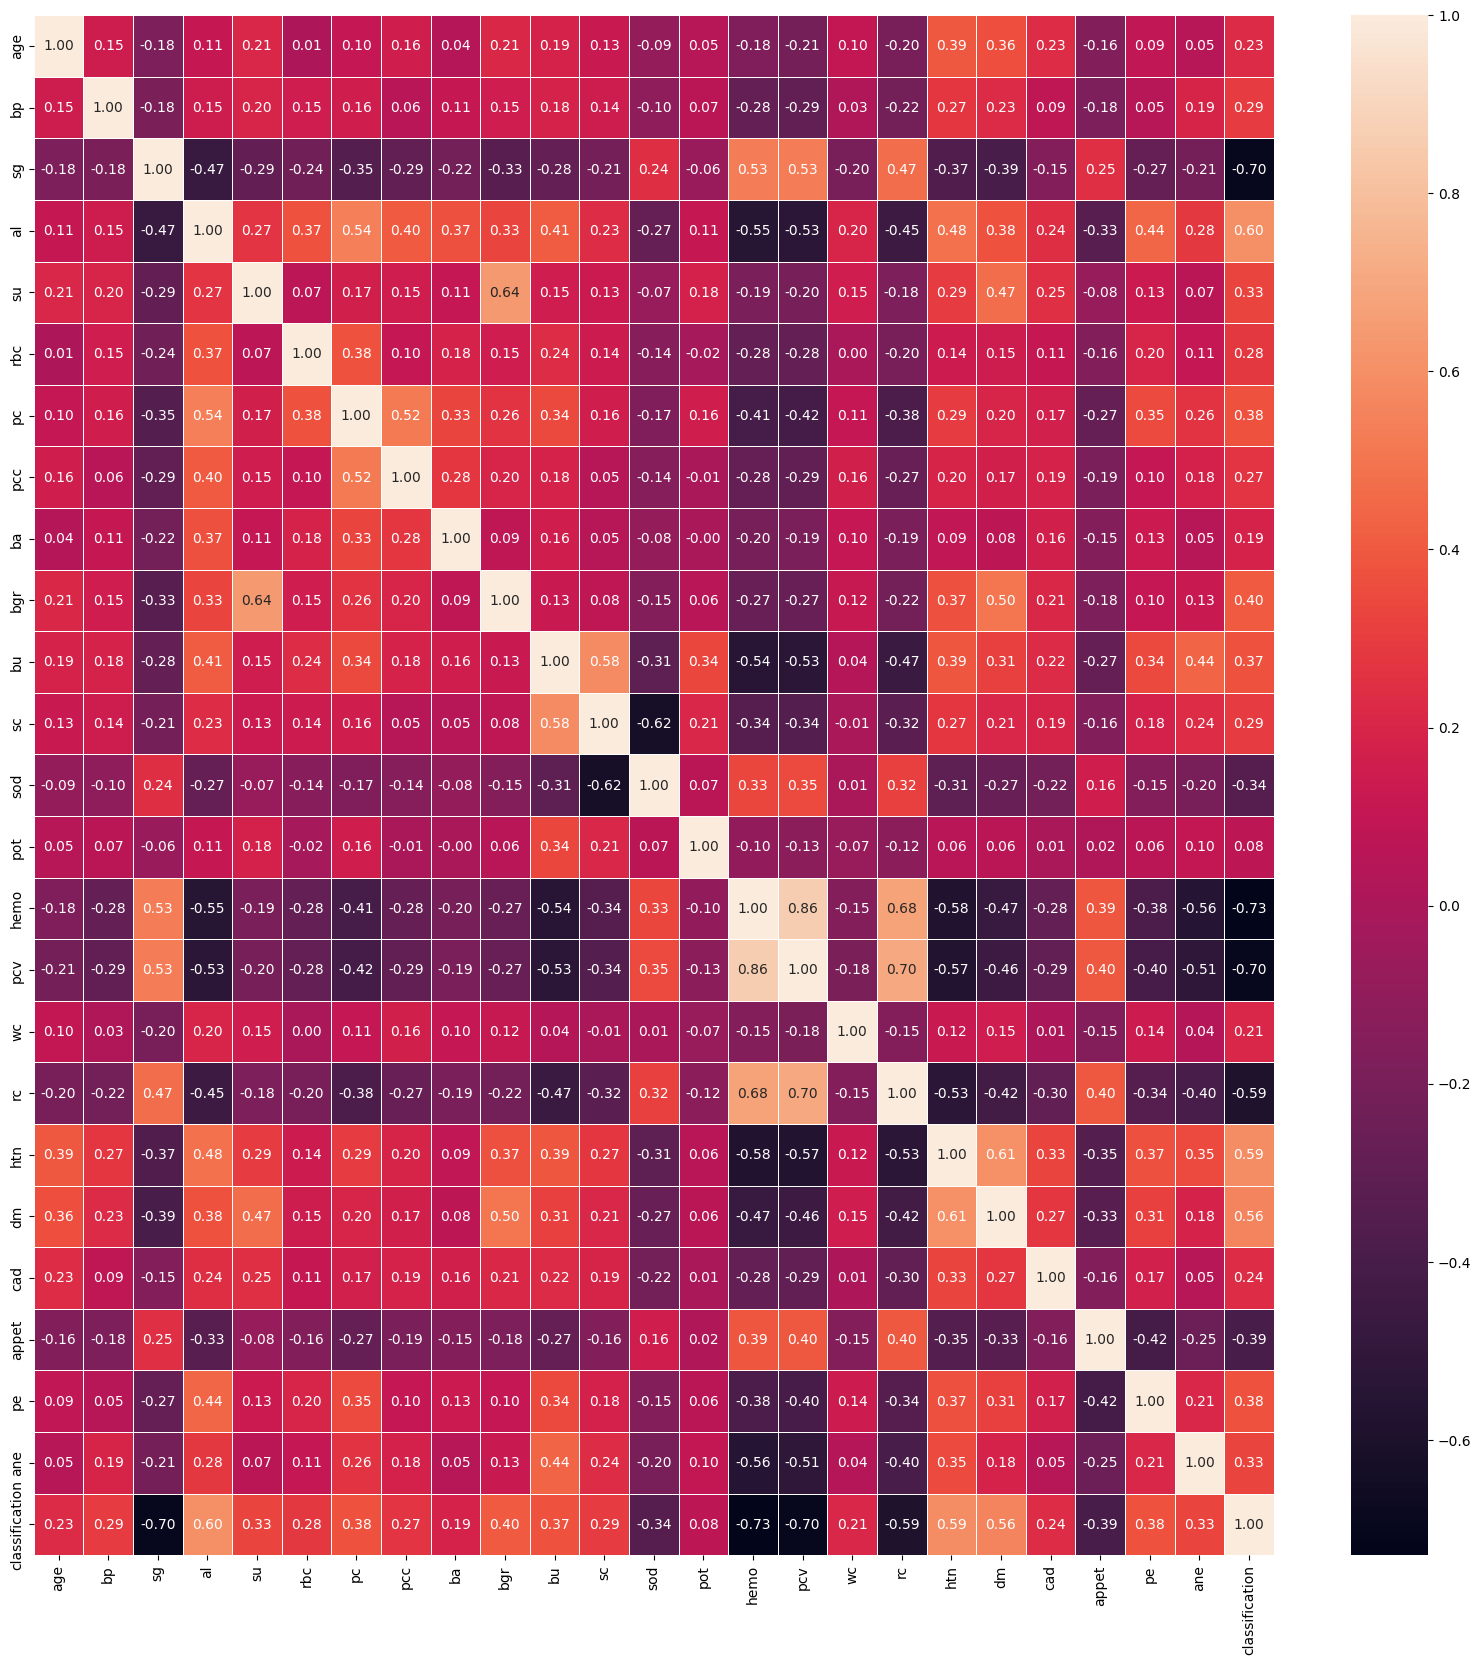

In [26]:
plt.figure(figsize = (20,20))
sns.heatmap(df.corr(), annot = True, fmt=".2f",linewidths=0.5)

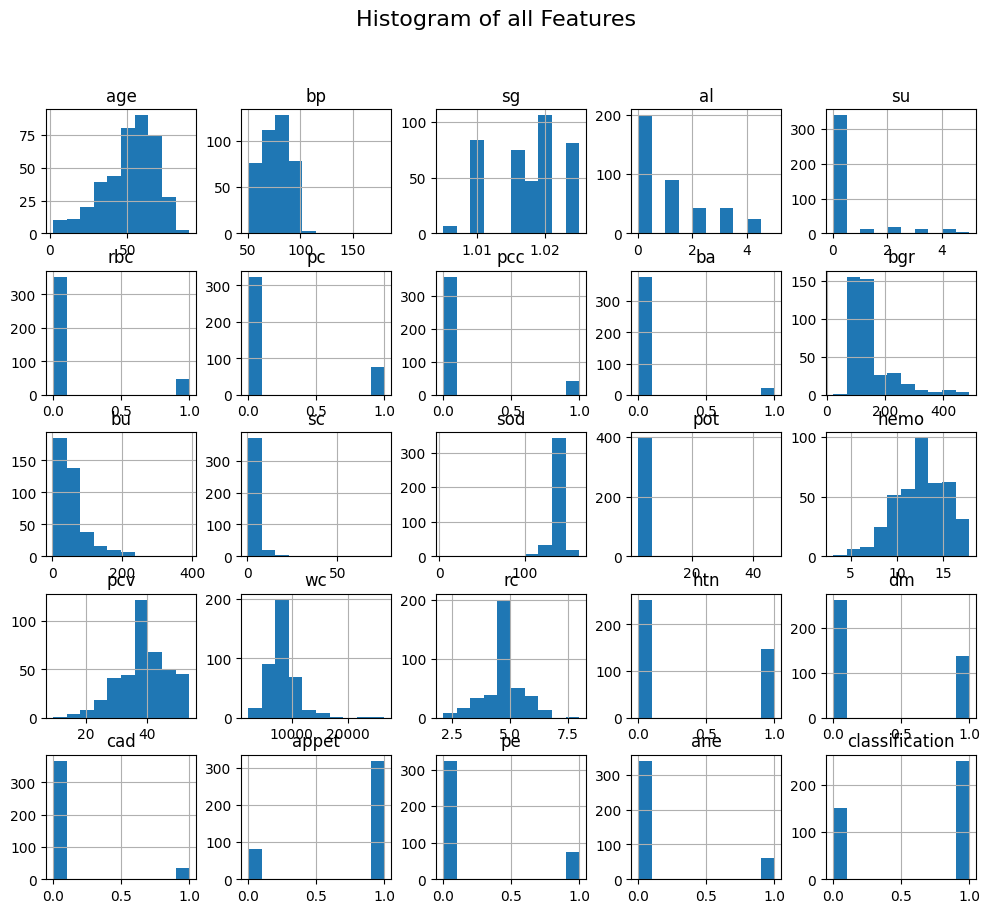

In [27]:
df.hist(figsize=(12,10))
plt.suptitle("Histogram of all Features",fontsize=16)
plt.show()

Text(0.5, 1.0, 'bgr vs Classification')

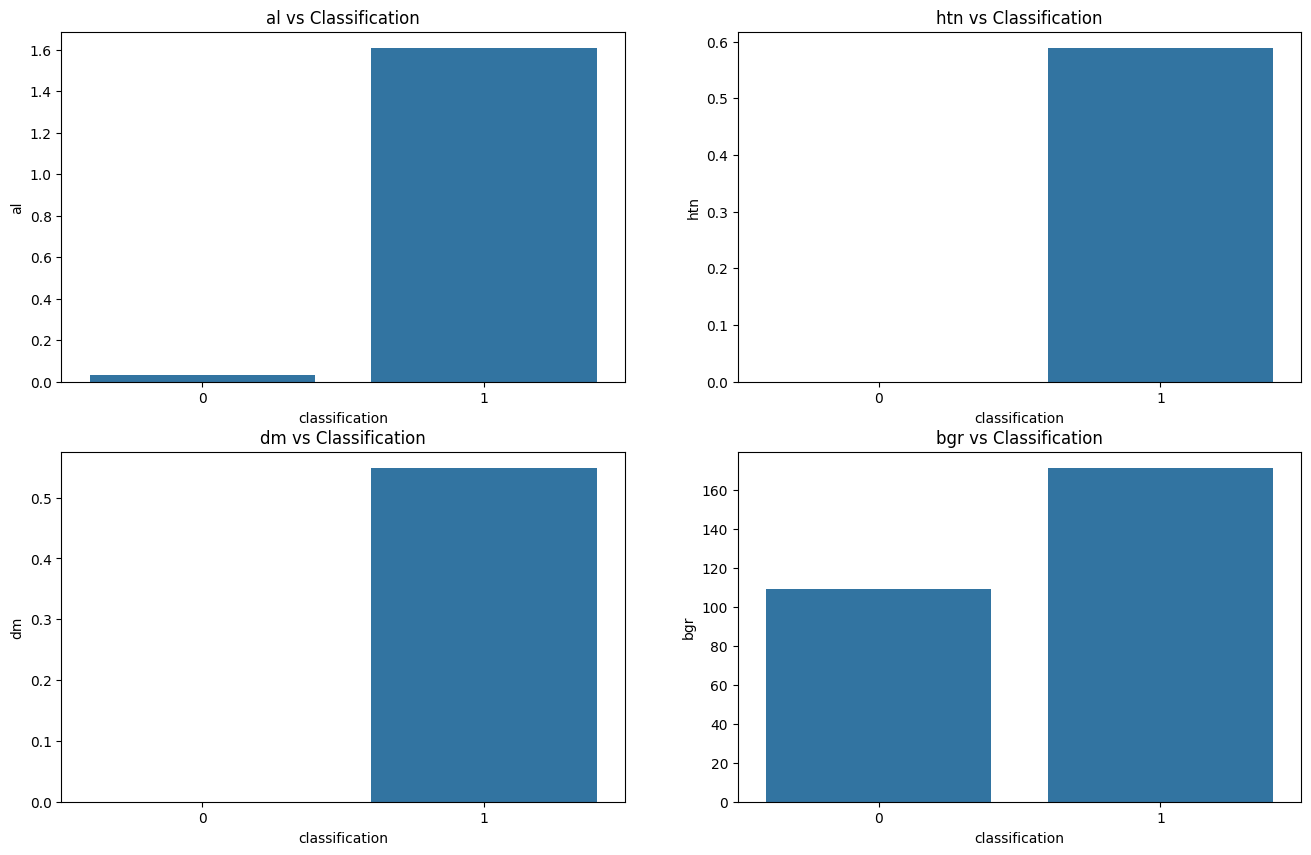

In [28]:
grouped = df.groupby("classification").mean()
fig, axes = plt.subplots(2, 2,figsize=(16, 10))

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

sns.barplot(x=grouped.index, y=grouped["al"], ax=ax1)
ax1.set_title("al vs Classification")

sns.barplot(x=grouped.index, y=grouped["htn"], ax=ax2)
ax2.set_title("htn vs Classification")

sns.barplot(x=grouped.index, y=grouped["dm"], ax=ax3)
ax3.set_title("dm vs Classification")

sns.barplot(x=grouped.index, y=grouped["bgr"], ax=ax4)
ax4.set_title("bgr vs Classification")

In [29]:
X = df.drop(['classification', 'sg', 'appet', 'rc', 'pcv', 'hemo', 'sod'], axis = 1)
y = df['classification']

In [30]:
X.columns

Index(['age', 'bp', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc',
       'pot', 'wc', 'htn', 'dm', 'cad', 'pe', 'ane'],
      dtype='object')

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
print("Training Data Shape",X_train.shape)
print("Test Data Shape",X_test.shape)

Training Data Shape (320, 18)
Test Data Shape (80, 18)


In [33]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 20)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [36]:
y_pred= model.predict(X_test)

In [37]:
print("Performance Metrics of Random Forest Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred))

Performance Metrics of Random Forest Model are:
Accuracy score:
0.9375
confusion matrix:
[[26  2]
 [ 3 49]]
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91        28
           1       0.96      0.94      0.95        52

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



<Axes: >

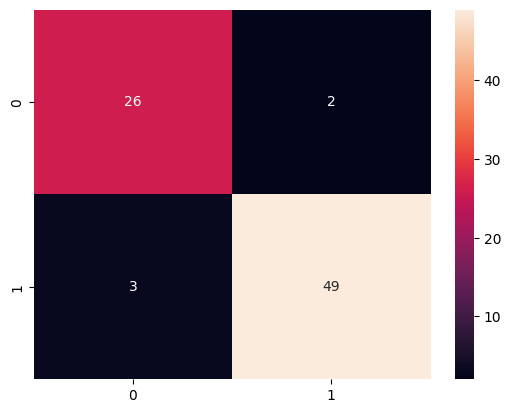

In [38]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

In [ ]:
import joblib
joblib.dump(model,"Kidney.joblib")

['Kidney.joblib']